<div style="text-align: justify; max-width: 90ch">

# Lecture 01c: Prompts as code, roles, and structured output

**Status: Mandatory reading.**

`lec_01b` chose the model. Now the other half of every call: the text you send. In a chat window a prompt is something you type once and lose;
in a system it is **code**: written as a function, versioned, tested, and its output parsed by a program, not read by a person.

**What this notebook covers**

- A prompt as a Python function with a version.
- The three **roles** (`system`, `user`, `assistant`) and why a model has no memory.
- **Few-shot** examples: showing instead of telling.
- **Structured output**: making the model return JSON that matches a schema, so pandas can take it from there.
- Streaming, for the user who is waiting.

</div>

In [1]:
import json

import ollama
import pandas as pd

In [2]:
# --- Course configuration: edit TIER only -------------------------------------
TIER = "cpu"  # 8-16 GB RAM, no GPU (default)
# TIER = "gpu"  # >= 8 GB VRAM: bigger, better answers (pull qwen3:8b first)

import os
from pathlib import Path

TIER = os.environ.get("COURSE_TIER", TIER)  # tools/run_all.py can override
os.environ.setdefault(
    "HF_HUB_DISABLE_PROGRESS_BARS", "1"
)  # no download bars in saved outputs
CHAT_MODEL = {"cpu": "qwen3:1.7b", "gpu": "qwen3:8b"}[TIER]
EMBED_MODEL = "nomic-embed-text"
OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
MLFLOW_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://127.0.0.1:5010")
EXPERIMENT = "llm-course-01-basics"
REPO = Path.cwd().resolve().parents[1]  # this notebook runs from reading_material/
DATA_DIR = REPO / "data"  # gitignored runtime state (indexes, caches)

from llm_course.checks import check_ollama

check_ollama(OLLAMA_HOST, [CHAT_MODEL])

Ollama OK at http://localhost:11434; models ready: qwen3:1.7b


<div style="text-align: justify; max-width: 90ch">

## 1. A prompt is a function

The same question asked five slightly different ways gives five different answers, and nobody remembers which wording produced the good one.
The fix is the one you know from the Python course: put it in a function with named inputs, and give it a version.

We also define `ask`, a two-line wrapper around `client.chat` with the course defaults (thinking off, temperature 0), so the rest of the notebook shows the prompts,
not the plumbing.

</div>

In [3]:
client = ollama.Client(host=OLLAMA_HOST)

PROMPT_VERSION = "v1"


def build_prompt(question, style="one sentence"):
    """Wrap a student's question with the instructions we want the model to follow."""
    return f"You are answering a question from a Python course. Reply in {style}.\n\nQuestion: {question}"


def ask(prompt, system=None, **options):
    """Send one prompt (plus an optional system message) and return the answer text."""
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})
    response = client.chat(
        model=CHAT_MODEL,
        messages=messages,
        think=False,
        options={"temperature": 0, "num_predict": 200, **options},
    )
    return response.message.content.strip()

In [4]:
question = "What does the axis argument mean in pandas drop()?"

print(ask(build_prompt(question)))
print("---")
print(ask(build_prompt(question, style="a bulleted list of at most three points")))

The `axis` argument in pandas' `drop()` method specifies whether to drop rows or columns.
---


- The `axis` argument in `pandas.drop()` specifies whether to drop rows or columns.  
- `axis=0` drops rows, and `axis=1` drops columns.  
- It allows you to remove specific rows or columns from a DataFrame.


<div style="text-align: justify; max-width: 90ch">

Two calls, one function, one variable changed. When a colleague asks "which prompt did you use?", the answer is `build_prompt`, version `v1`, and a diff.

</div>

<div style="text-align: justify; max-width: 90ch">

## 2. Roles: system, user, assistant

A chat call is a **list of messages**, each with a role:

| Role | Who writes it | Typical content |
| --- | --- | --- |
| `system` | you, once | who the model is, rules it must follow, the language to answer in |
| `user` | the person (or your code) | the question |
| `assistant` | the model | its previous answers |

The **system prompt** is where product rules live: tone, language, refusals, format. Same question, two system prompts.

</div>

In [5]:
tutor = (
    "You are a teaching assistant for a Python course. Answer in at most two sentences."
)
tutor_greek = tutor + " Always answer in Greek."

print(ask(question, system=tutor))
print("---")
print(ask(question, system=tutor_greek))

The `axis` argument in `pandas.drop()` specifies whether to drop the specified labels from a row (axis=0) or column (axis=1).
---


Η αξία της διατροφής στο pandas drop() είναι η επιλογή της στήλης ή της γραμμής που θέλετε να αφαιρεθεί.


<div style="text-align: justify; max-width: 90ch">

Read the Greek answer against the English one before trusting it: small models are weaker in less common languages, and a confident wrong answer in Greek is exactly the *languages* requirement from `lec_01b` failing quietly.

Now the part that surprises everyone: **the model has no memory**. Every call starts from nothing; a conversation exists only because your code sends the previous messages again, with the `assistant` role.

</div>

In [6]:
# WRONG: the second question alone; the model has never seen the first exchange
follow_up = "Can you show a one-line example of it?"
print(ask(follow_up, system=tutor))

Sure! Here's a one-line example: `print("Hello, world!")`


In [7]:
# RIGHT: resend the history, then the follow-up
history = [
    {"role": "system", "content": tutor},
    {"role": "user", "content": question},
    {"role": "assistant", "content": ask(question, system=tutor)},
    {"role": "user", "content": follow_up},
]
response = client.chat(
    model=CHAT_MODEL,
    messages=history,
    think=False,
    options={"temperature": 0, "num_predict": 200},
)
print(response.message.content.strip())

For example: `df.drop(axis=1, labels=['column_name'])` removes the specified column from the DataFrame.


<div style="text-align: justify; max-width: 90ch">

Chat applications do exactly this behind the scenes, which is why long conversations get slower and eventually hit the context window from `lec_01a`.

</div>

<div style="text-align: justify; max-width: 90ch">

## 3. Few-shot examples

Describing a format in words works less well than showing two or three examples. Examples inside the prompt are called **few-shot** (zero-shot is the bare instruction).
Here the task is to tag a student's forum question with one category.

</div>

In [8]:
FEW_SHOT = """Tag the question with exactly one category: pandas, plots, sklearn, python-basics, or other.

Question: How do I read an Excel file into a DataFrame?
Category: pandas

Question: Why does my for loop print the last value only?
Category: python-basics

Question: Which metric should I use for an imbalanced classification?
Category: sklearn

Question: {question}
Category:"""

print(
    ask(
        FEW_SHOT.format(question="How do I change the colours in a seaborn heatmap?"),
        num_predict=10,
    )
)

Category: pandas


<div style="text-align: justify; max-width: 90ch">

## 4. Structured output

The answer above is text. To count categories, filter them, or plot them, a program has to **parse** it, and text parsing breaks the day the model adds a word.

</div>

In [9]:
# WRONG: parse free text and hope the format never changes
raw = ask(
    FEW_SHOT.format(question="My notebook kernel keeps dying when I load a big CSV"),
    num_predict=20,
)
print(repr(raw))
category = (
    raw.split(":")[-1].strip().strip(".").lower()
)  # breaks on "Category: **pandas** (probably)" or a two-line answer
print(category)

'Category: pandas'
pandas


<div style="text-align: justify; max-width: 90ch">

It worked this time. It works until the model answers `Category: **pandas** (probably)`, or adds a second line, and then a `KeyError` appears three cells later in a `groupby`.

The fix is to tell the model the *shape* of the answer, not the wording. A **JSON schema** is a dictionary that describes a JSON object:
which keys, which types, which allowed values (`enum`). Ollama takes it as `format=` and constrains generation so the output is always valid JSON of that shape;
no parsing code, no surprises.

</div>

In [10]:
CATEGORIES = """Categories:
- pandas: DataFrames, reading files, merging, grouping, missing values
- plots: charts and figures (matplotlib, seaborn, plotly)
- sklearn: models, metrics, train/test split, GridSearchCV, pipelines
- python-basics: syntax, loops, functions, errors, installing packages, the command line
- other: anything else (deployment, tools, accounts)"""

TAG_SCHEMA = {
    "type": "object",
    "properties": {
        "category": {
            "type": "string",
            "enum": ["pandas", "plots", "sklearn", "python-basics", "other"],
        },
        "needs_code": {"type": "boolean"},
        "summary": {
            "type": "string",
            "description": "the question in at most ten words",
        },
    },
    "required": ["category", "needs_code", "summary"],
}


def tag_question(question):
    """Return a dict with category, needs_code, summary for one forum question."""
    response = client.chat(
        model=CHAT_MODEL,
        messages=[
            {
                "role": "user",
                "content": f"Tag this Python-course forum question with one category.\n\n{CATEGORIES}\n\nQuestion: {question}",
            }
        ],
        format=TAG_SCHEMA,  # RIGHT: the model must return JSON matching the schema
        think=False,
        options={"temperature": 0, "num_predict": 100},
    )
    return json.loads(response.message.content)


tag_question("My notebook kernel keeps dying when I load a big CSV")

{'category': 'other',
 'needs_code': True,
 'summary': 'The question is about a notebook kernel dying when loading a big CSV, which is related to performance issues, memory management, or kernel stability in Jupyter notebooks.'}

<div style="text-align: justify; max-width: 90ch">

`json.loads` turns the text into a Python dict, and the `enum` guarantees the category is one of your five, spelled your way.
The category *definitions* in the prompt do the other half of the work: without them a small model tags most questions as `python-basics`.

</div>

<div style="text-align: justify; max-width: 90ch">

## 5. From answers to a DataFrame

Twelve real-looking forum questions, one call each, straight into pandas. The results are cached to a CSV in `data/` so re-running the notebook does not repeat the calls.

⏱ **Skip if running long.** Twelve calls take about a minute on a CPU; the cached CSV in `data/` (if present) is used instead.

</div>

In [11]:
forum_questions = [
    "How do I merge two DataFrames on a customer id?",
    "Why is my bar chart showing the categories in the wrong order?",
    "What is the difference between fit and fit_transform?",
    "My while loop never stops, what did I do wrong?",
    "How can I drop rows with missing values only in one column?",
    "Which plot shows the relationship between two numeric columns?",
    "GridSearchCV takes forever, how do I make it faster?",
    "What does if __name__ == '__main__' do?",
    "Can I deploy my Gradio app without a credit card?",
    "How do I group by month and sum the sales?",
    "Is accuracy a good metric when one class is rare?",
    "The pip install command says permission denied",
]

cache_path = DATA_DIR / "lec_01c_tagged_questions.csv"
DATA_DIR.mkdir(exist_ok=True)

if cache_path.exists():
    tagged = pd.read_csv(cache_path)
else:
    tagged = pd.DataFrame([{"question": q, **tag_question(q)} for q in forum_questions])
    tagged.to_csv(cache_path, index=False)

tagged

,question,category,needs_code,summary
0,How do I merge two DataFrames on a customer id?,pandas,True,Merge two DataFrames on a customer id
1,Why is my bar chart showing the categories in ...,plots,False,The question is about why a bar chart is displ...
2,What is the difference between fit and fit_tra...,sklearn,True,Explains the difference between fit and fit_tr...
3,"My while loop never stops, what did I do wrong?",python-basics,False,Identifies the issue with an infinite while lo...
4,How can I drop rows with missing values only i...,pandas,True,How to drop rows with missing values only in o...
5,Which plot shows the relationship between two ...,plots,False,This question is about identifying a plot type...
6,"GridSearchCV takes forever, how do I make it f...",sklearn,False,Optimizing GridSearchCV performance
7,What does if __name__ == '__main__' do?,python-basics,False,Explains the purpose of the if __name__ == '__...
8,Can I deploy my Gradio app without a credit card?,other,False,The question is about deploying a Gradio app w...
9,How do I group by month and sum the sales?,pandas,True,How do I group by month and sum the sales?


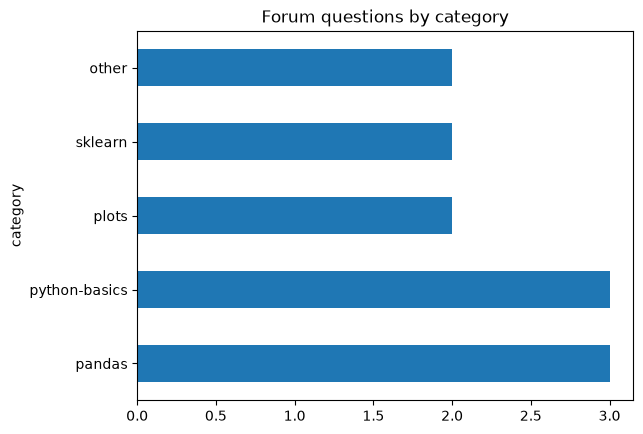

In [12]:
tagged["category"].value_counts().plot(
    kind="barh", title="Forum questions by category"
);

<div style="text-align: justify; max-width: 90ch">

### ⏸ Pause point

Look at the rows, not the plot: would you have tagged each one the same way? Where you disagree with the model is exactly where lecture 3 starts:
measuring how often it is right.

</div>

<div style="text-align: justify; max-width: 90ch">

## 6. Streaming

Everything so far waited for the full answer. A person watching a screen prefers to see words appear; `stream=True` returns the answer in pieces as they are generated.

</div>

In [13]:
stream = client.chat(
    model=CHAT_MODEL,
    messages=[
        {
            "role": "user",
            "content": build_prompt(
                "Why do we split data before scaling it?", style="three sentences"
            ),
        }
    ],
    think=False,
    stream=True,
    options={"temperature": 0, "num_predict": 120},
)
for chunk in stream:
    print(chunk.message.content, end="", flush=True)
print()

We

 split

 data

 before

 scaling

...

 bias

 from

 scaled

 data

.

<div style="text-align: justify; max-width: 90ch">

## Recap

- A prompt is a **function** with named inputs and a version, not a string you retype.
- Messages have **roles**; the system prompt carries the product rules; the model remembers nothing, your code resends the history.
- **Few-shot** examples show the format instead of describing it.
- **Structured output** (`format=` a JSON schema) turns answers into dicts you can trust, and then into DataFrames.
- `stream=True` gives the user words while the model is still writing.

**Next: `lec_01d`**, the same ideas with LangChain, a library that names these parts (prompt template, chain, parser), plus MLflow tracing to see exactly what was sent and returned.

</div>